# 트랜스포머 모델 스터디 1주차
GPT-2의 가중치 랭크, QK·OV 회로, 임베딩 기준 residual 변화, OV 고유분해를 분석합니다.

## 사전 준비
GPT-2와 TransformerLens를 사용합니다. GPT-2의 residual 차원은 $d_{\mathrm{model}}=768$, 헤드 수는 $H=12$, 헤드 차원은 $d_{\mathrm{head}}=64$입니다.
[원 논문](https://transformer-circuits.pub/2021/framework/index.html)처럼 입력을 열벡터로 두고 $Wx$ 순서로 계산합니다. TransformerLens의 가중치는 전치하여 분석용 행렬로 사용합니다.

In [1]:
import os
os.environ["TRANSFORMERLENS_ALLOW_MPS"] = "1"

import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from IPython.display import HTML, display
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from importlib.metadata import version
from transformer_lens.model_bridge import TransformerBridge

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2})
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
model = TransformerBridge.boot_transformers("openai-community/gpt2", device=device)
model.eval()
print("device:", device)
print({name: version(name) for name in ["torch", "transformer-lens", "transformers"]})
print(f"layers={model.cfg.n_layers}, heads={model.cfg.n_heads}, d_model={model.cfg.d_model}, d_head={model.cfg.d_head}")

/Users/meltdown/Desktop/projects/Mechanistic-Interpretability-study/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11363.56it/s]

device: mps
{'torch': '2.14.0', 'transformer-lens': '4.0.0', 'transformers': '5.17.0'}
layers=12, heads=12, d_model=768, d_head=64


In [2]:
# 랭크 지표, 전체 projection 복원, 저랭크 분해, 랭크 그래프
def cpu_float64(tensor):
    # Move first, cast second: combined MPS->CPU float64 transfer can corrupt values.
    return tensor.detach().cpu().to(dtype=torch.float64)


def rank_metrics(singular_values):
    """sigma^2-normalized entropy rank, participation ratio, and 95% dimension."""
    # Rescale before squaring for invariance even at very small/large magnitudes.
    scale = singular_values.abs().amax(dim=-1, keepdim=True)
    scaled = singular_values / torch.where(scale > 0, scale, torch.ones_like(scale))
    energy = scaled.square()
    total = energy.sum(dim=-1, keepdim=True)
    p = energy / torch.where(total > 0, total, torch.ones_like(total))
    nonzero = total.squeeze(-1) > 0
    entropy = -torch.special.xlogy(p, p).sum(dim=-1)
    concentration = p.square().sum(dim=-1)
    participation = 1 / torch.where(nonzero, concentration, torch.ones_like(concentration))
    cumulative = p.sort(dim=-1, descending=True).values.cumsum(dim=-1)
    # Include exact 95% boundaries despite floating-point rounding.
    tol = 10 * torch.finfo(p.dtype).eps
    dimension = (cumulative < 0.95 - tol).sum(dim=-1) + 1
    return {
        "Entropy rank": torch.where(nonzero, entropy.exp(), torch.zeros_like(entropy)),
        "Participation ratio": torch.where(nonzero, participation, torch.zeros_like(participation)),
        "95% dimension": torch.where(nonzero, dimension, torch.zeros_like(dimension)),
    }


def full_projection_matrices(weights):
    """Assemble full projections in the paper's column-vector convention."""
    full = {}
    for name, w in weights.items():
        n_layers, n_heads = w.shape[:2]
        if name == "O":
            # O: concatenate head outputs horizontally, [d_model, n_heads*d_head].
            full[name] = w.permute(0, 2, 1, 3).reshape(n_layers, w.shape[2], n_heads * w.shape[3])
        else:
            # Q/K/V: stack head projections vertically, [n_heads*d_head, d_model].
            full[name] = w.reshape(n_layers, n_heads * w.shape[2], w.shape[3])
    return full


def product_singular_values(a, b):
    """Nonzero spectrum of AB via thin QR; supports batch dimensions."""
    _, ra = torch.linalg.qr(a, mode="reduced")
    _, rb = torch.linalg.qr(b.transpose(-2, -1), mode="reduced")
    return torch.linalg.svdvals(ra @ rb.transpose(-2, -1))


def product_eigensystem(a, b):
    """Nonzero right eigenmodes of AB, lifted from BA; zero modes omitted."""
    values, small_vectors = torch.linalg.eig(b @ a)
    tol = torch.finfo(a.dtype).eps * a.shape[-1] * values.abs().max().clamp_min(1)
    keep = values.abs() > tol
    values = values[keep]
    vectors = a.to(small_vectors.dtype) @ small_vectors[:, keep]
    vectors = vectors / vectors.norm(dim=0, keepdim=True)
    return values, vectors


def plot_rank_metrics(results, title, ceiling, per_head=False):
    """Three panels; full matrices are one line each, circuits summarize heads."""
    metric_names = ["Entropy rank", "Participation ratio", "95% dimension"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
    for ax, metric in zip(axes, metric_names):
        for name, metrics in results.items():
            data = metrics[metric].numpy()
            y = data.mean(axis=1) if per_head else data
            line, = ax.plot(layers, y, "o-", markersize=3, label=name)
            if per_head:
                ax.fill_between(layers, data.min(axis=1), data.max(axis=1),
                                color=line.get_color(), alpha=0.12)
        ax.axhline(ceiling, color="gray", linestyle=":", linewidth=1, label=f"Ceiling: {ceiling}")
        ax.set(title=metric, xlabel="Layer (0-based)", ylabel="Dimensions", xticks=layers, ylim=(0, ceiling * 1.05))
        ax.legend(fontsize=8, ncol=2)
    fig.suptitle(title)
    plt.show()


def circuit_matrix_rank(circuit_factors):
    """Direct matrix_rank on actual 768x768 products, one layer at a time."""
    ranks = {}
    for name, (a, b) in circuit_factors.items():
        ranks[name] = torch.stack([
            torch.linalg.matrix_rank(a_layer @ b_layer)
            for a_layer, b_layer in zip(a, b)
        ])
    return ranks


def show_matrix_rank(ranks, per_head=False):
    """Compact numerical rank table, preceding the effective-rank plots."""
    print("torch.linalg.matrix_rank | CPU float64 | default tolerance")
    if per_head:
        print("Layer  " + "  ".join(f"{name:>16}" for name in ranks))
        print("       " + "  ".join(f"{'mean [min, max]':>16}" for _ in ranks))
        for layer in layers:
            values = [f"{r[layer].double().mean():5.1f} [{r[layer].min():2d}, {r[layer].max():2d}]" for r in ranks.values()]
            print(f"{layer:5d}  " + "  ".join(f"{value:>16}" for value in values))
    else:
        print("Layer  " + "  ".join(f"{name:>5}" for name in ranks))
        for layer in layers:
            print(f"{layer:5d}  " + "  ".join(f"{r[layer]:5d}" for r in ranks.values()))

In [3]:
# Prefill / KV-cache decode 측정 및 시각화
def residual_delta(cache):
    return torch.stack([
        (cache[f"blocks.{layer}.hook_resid_post"] - cache["blocks.0.hook_resid_pre"])[0]
        .detach().float().cpu() for layer in layers
    ])


def trace_residual_stream(model, prompt, n_decode):
    assert prompt.strip(), "prompt must not be empty."
    assert isinstance(n_decode, int) and n_decode >= 1
    prompt_tokens = model.to_tokens(prompt, prepend_bos=False)
    assert prompt_tokens.shape[1] + n_decode <= model.cfg.n_ctx
    resid_names = [f"blocks.{layer}.hook_resid_{part}"
                   for layer in layers for part in ("pre", "post")]


    with torch.inference_mode():
        (logits, kv_cache), prefill_cache = model.run_with_cache(
            prompt_tokens, names_filter=resid_names, return_type="logits_and_cache", use_cache=True)
        prefill_delta = residual_delta(prefill_cache)
        next_token = logits[:, -1].argmax(dim=-1, keepdim=True)
        generated_ids, decode_steps = [], []
        for step in range(n_decode):
            generated_ids.append(next_token.item())
            (logits, kv_cache), step_cache = model.run_with_cache(
                next_token, past_key_values=kv_cache, names_filter=resid_names,
                return_type="logits_and_cache")
            delta = residual_delta(step_cache)
            assert delta.shape[1] == 1, "Decode must process exactly one new token."
            decode_steps.append(delta[:, 0])
            next_token = logits[:, -1].argmax(dim=-1, keepdim=True)
            del step_cache
            if generated_ids[-1] == model.tokenizer.eos_token_id:
                break
        decode_delta = torch.stack(decode_steps, dim=1)
        # Independent full-prefix forward verifies cache positions and decoding semantics.
        full_tokens = torch.cat([prompt_tokens, torch.tensor([generated_ids], device=prompt_tokens.device)], dim=1)
        full_logits, full_cache = model.run_with_cache(full_tokens, names_filter=resid_names)
        full_delta = residual_delta(full_cache)
        expected_embedding = model.W_E[full_tokens] + model.W_pos[:full_tokens.shape[1]]
        torch.testing.assert_close(full_cache["blocks.0.hook_resid_pre"], expected_embedding, atol=1e-5, rtol=1e-5)
        torch.testing.assert_close(prefill_delta, full_delta[:, :prompt_tokens.shape[1]], atol=3e-3, rtol=3e-3)
        torch.testing.assert_close(decode_delta, full_delta[:, prompt_tokens.shape[1]:], atol=3e-3, rtol=3e-3)
        torch.testing.assert_close(logits[:, -1], full_logits[:, -1], atol=3e-3, rtol=3e-3)
        del prefill_cache, full_cache, full_logits, full_delta, kv_cache

    prompt_labels = [repr(model.tokenizer.decode([i])) for i in prompt_tokens[0].tolist()]
    decode_labels = [f"{i+1}: {model.tokenizer.decode([token])!r}" for i, token in enumerate(generated_ids)]
    print("Prompt:", prompt)
    print("Continuation:", model.tokenizer.decode(generated_ids))
    print("Shapes [layer, token/step, d_model]:", tuple(prefill_delta.shape), tuple(decode_delta.shape))
    print("PASS: baseline = token + position embeddings; cached decode agrees with full-prefix forward.")
    return {
        "prefill_delta": prefill_delta, "decode_delta": decode_delta,
        "prompt_labels": prompt_labels, "decode_labels": decode_labels,
        "generated_ids": generated_ids,
    }


def decode_snapshot(result, step, layer):
    """Mask prefix rows to zero for display; preserve the current token embedding diff."""
    prefill, decode = result["prefill_delta"], result["decode_delta"]
    assert 0 <= step < decode.shape[1]
    assert -1 <= layer < decode.shape[0]
    history = decode.new_zeros((prefill.shape[1] + step, decode.shape[2]))
    current = torch.zeros_like(decode[0, step]) if layer == -1 else decode[layer, step]
    return torch.cat([history, current.unsqueeze(0)], dim=0)


def plot_residual_stream(result):
    """One layer slider; decode is fixed to its first generated token."""
    prefill = result["prefill_delta"].numpy()
    decode = result["decode_delta"][:, :1].numpy()
    labels = [f"{i}: {label}" for i, label in enumerate(result["prompt_labels"])]
    labels += [f"{len(labels) + i}: {label}" for i, label in enumerate(result["decode_labels"][:1])]
    initial = [np.zeros_like(prefill[0]), decode_snapshot(result, 0, -1).numpy()]
    limit = max(float(np.abs(prefill).max()), float(np.abs(decode).max()), 1e-12)
    ticks = np.array([-1000, -100, -10, -1, 0, 1, 10, 100, 1000], dtype=float)
    ticks = ticks[np.abs(ticks) <= limit]
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.12,
                        subplot_titles=["Prefill: all prompt tokens", "Decode step 1: only the last row is active"])
    for row, raw in enumerate(initial, start=1):
        token_labels = labels[:len(raw)]
        fig.add_trace(go.Heatmap(
            z=np.sign(raw) * np.log10(1 + np.abs(raw)), customdata=raw,
            y=token_labels, x=np.arange(raw.shape[-1]), coloraxis="coloraxis", zsmooth=False,
            hovertemplate="Token: %{y}<br>Coordinate: %{x}<br>Delta from embedding: %{customdata:.5g}<extra></extra>",
        ), row=row, col=1)
    color_limit = np.log10(1 + limit)
    fig.update_layout(
        title="Delta from token + position embeddings | Input (before block 0)",
        height=max(660, 260 + 14 * (2 * prefill.shape[1] + decode.shape[1])),
        margin=dict(l=195, r=100, t=80, b=55), template="plotly_white",
        coloraxis=dict(colorscale="RdBu_r", cmin=-color_limit, cmax=color_limit,
                       colorbar=dict(title="Signed delta", tickvals=np.sign(ticks) * np.log10(1 + np.abs(ticks)),
                                     ticktext=[f"{tick:g}" for tick in ticks])),
    )
    fig.update_yaxes(autorange="reversed", type="category", title_text="Token")
    fig.update_xaxes(title_text="Residual coordinate (0–767)", row=2, col=1)
    # Serialize data once, rather than repeating the prefix for every step/layer pair.
    payload = json.dumps(dict(prefill=prefill.tolist(), decode=decode.tolist(), labels=labels))
    script = r"""
    const gd = document.getElementById('{plot_id}');
    const payload = PAYLOAD;
    const prefill = payload.prefill, decode = payload.decode, labels = payload.labels;
    const nPrompt = prefill[0].length, nLayers = prefill.length;
    const zeros = () => Array(prefill[0][0].length).fill(0);
    const signedLog = rows => rows.map(row => row.map(x => Math.sign(x) * Math.log10(1 + Math.abs(x))));
    const controls = document.createElement('div');
    controls.style.cssText = 'display:flex;gap:28px;flex-wrap:wrap;padding:12px 20px;font:14px sans-serif';
    function slider(caption, min, max, value) {
        const label = document.createElement('label');
        const text = document.createElement('span');
        const input = document.createElement('input');
        input.type = 'range'; input.min = min; input.max = max; input.value = value; input.step = 1;
        input.style.cssText = 'width:240px;vertical-align:middle;margin-left:12px';
        input.setAttribute('aria-label', caption);
        label.append(text, input); controls.append(label);
        return {text, input};
    }
    const layerControl = slider('Layer', -1, nLayers - 1, -1);
    gd.parentNode.insertBefore(controls, gd);
    function render() {
        const layer = Number(layerControl.input.value);
        const layerText = layer < 0 ? 'Input' : 'After block ' + layer;
        layerControl.text.textContent = 'Layer: ' + layerText;
        const promptRows = layer < 0 ? prefill[0].map(zeros) : prefill[layer];
        const currentRow = layer < 0 ? zeros() : decode[layer][0];
        // Display mask: previous token rows are zero; source deltas remain unchanged.
        const decodeRows = Array.from({length: nPrompt}, zeros).concat([currentRow]);
        const decodeLabels = labels.slice(0, nPrompt + 1);
        const raw = [promptRows, decodeRows];
        const ys = [labels.slice(0, nPrompt), decodeLabels];
        const traces = gd.data.map((trace, i) => Object.assign({}, trace, {
            z: signedLog(raw[i]), customdata: raw[i], y: ys[i]
        }));
        const layout = Object.assign({}, gd.layout, {
            title: {text: 'Delta from token + position embeddings | ' + layerText},
            yaxis: Object.assign({}, gd.layout.yaxis, {autorange: 'reversed'}),
            yaxis2: Object.assign({}, gd.layout.yaxis2, {autorange: 'reversed'})
        });
        Plotly.react(gd, traces, layout, {responsive: true});
    }
    layerControl.input.addEventListener('input', render);
    render();
    """.replace("PAYLOAD", payload.replace("<", "\\u003c"))
    return HTML(fig.to_html(full_html=False, include_plotlyjs=True, post_script=script))


In [4]:
# OV 고윳값과 고유벡터 시각화
def plot_circuit_spectra(circuit_factors):
    eigenvalues = {}
    positive_real_fraction = {}
    for name, (a, b) in circuit_factors.items():
        eig = torch.linalg.eigvals(b @ a)  # [layer, head, d_head]
        tol = 1e-8 * eig.abs().amax(dim=-1, keepdim=True).clamp_min(1)
        nonzero = eig.abs() > tol
        positive_real = (eig.imag.abs() <= tol) & (eig.real > tol)
        eigenvalues[name] = eig
        positive_real_fraction[name] = positive_real.sum(dim=-1) / nonzero.sum(dim=-1).clamp_min(1)

    fig, axes = plt.subplots(1, len(circuit_factors), figsize=(6 * len(circuit_factors), 4), layout="constrained")
    axes = np.atleast_1d(axes)
    for ax, (name, fraction) in zip(axes, positive_real_fraction.items()):
        im = ax.imshow(fraction.numpy(), origin="lower", aspect="auto", vmin=0, vmax=1, cmap="viridis")
        ax.set(title=f"{name}: positive-real / nonzero eigenvalues", xlabel="Head", ylabel="Layer",
               xticks=np.arange(model.cfg.n_heads), yticks=layers)
        ax.grid(False)
    fig.colorbar(im, ax=axes, label="Fraction (not a copying probability)")
    plt.show()
    return eigenvalues, positive_real_fraction


def plot_ov_eigenvalue_grid(values):
    """Paper-style polar spectra: rows=layers, columns=heads, log magnitude radius."""
    eig = values.detach().cpu().numpy()
    tolerance = 1e-8 * np.maximum(np.abs(eig).max(axis=-1, keepdims=True), 1)
    nonzero = np.abs(eig) > tolerance
    magnitudes = np.abs(eig[nonzero])
    lower = int(np.floor(np.log10(magnitudes.min())))
    upper = int(np.ceil(np.log10(magnitudes.max())))
    # Shift log radii above zero; every panel uses identical decade rings.
    decades = np.arange(lower, upper + 1, max(1, int(np.ceil((upper - lower) / 3))))
    radial_ticks = decades - lower + 1
    n_layers, n_heads = eig.shape[:2]
    fig, axes = plt.subplots(n_layers, n_heads, figsize=(24, 24),
                             subplot_kw={"projection": "polar"}, squeeze=False)
    for layer in range(n_layers):
        for head in range(n_heads):
            ax = axes[layer, head]
            z = eig[layer, head, nonzero[layer, head]]
            positive = (np.abs(z.imag) <= tolerance[layer, head, 0]) & (z.real > tolerance[layer, head, 0])
            theta = np.angle(z)
            radius = np.log10(np.abs(z)) - lower + 1
            ax.scatter(theta[~positive], radius[~positive], s=3.5, color="#2496c8", alpha=0.8, linewidths=0)
            ax.scatter(theta[positive], radius[positive], s=5, color="#cf6848", alpha=0.95, linewidths=0)
            ax.set_theta_zero_location("E")
            ax.set_thetagrids([0, 90, 180, 270], labels=["", "", "", ""])
            ax.set_ylim(0, upper - lower + 1.25)
            ax.set_yticks(radial_ticks)
            ax.set_yticklabels([rf"$10^{{{d}}}$" for d in decades], fontsize=4.5, color="#777777")
            ax.set_rlabel_position(45)
            ax.grid(True, color="#d6d6d6", linewidth=0.4, alpha=0.8)
            ax.spines["polar"].set_color("#b8b8b8")
            ax.spines["polar"].set_linewidth(0.5)
            if layer == 0:
                ax.set_title(f"H{head}", fontsize=10, pad=8)
            if head == 0:
                ax.text(-0.24, 0.5, f"L{layer}", transform=ax.transAxes,
                        ha="right", va="center", fontsize=11, fontweight="bold")
    fig.suptitle("OV eigenvalues | all GPT-2 layers and heads", fontsize=19, y=0.985)
    fig.text(0.5, 0.967,
             "Angle = arg(lambda); radius = log magnitude | right: positive real; left: negative real",
             ha="center", fontsize=11, color="#555555")
    fig.text(0.5, 0.953,
             "Orange: positive-real eigenvalues | Blue: other nonzero eigenvalues | Shared scale; zero modes omitted",
             ha="center", fontsize=10, color="#555555")
    fig.subplots_adjust(left=0.05, right=0.99, bottom=0.03, top=0.93, wspace=0.20, hspace=0.18)
    # Vector output preserves legibility when the 144 panels are enlarged.
    import io
    from IPython.display import SVG
    buffer = io.StringIO()
    fig.savefig(buffer, format="svg", bbox_inches="tight")
    plt.close(fig)
    display(SVG(buffer.getvalue()))
    print(f"{n_layers} layers x {n_heads} heads | {nonzero.sum()} nonzero eigenvalues displayed")
    return fig


In [5]:
# Convert TransformerLens storage (x @ W) to the paper convention (W @ x).
weights = {name: cpu_float64(getattr(model, f"W_{name}")).transpose(-2, -1).contiguous()
           for name in ("Q", "K", "V", "O")}
assert all(torch.isfinite(w).all() and w.norm() > 0 for w in weights.values())
layers = np.arange(model.cfg.n_layers)
full_weights = full_projection_matrices(weights)
assert all(w.shape == (12, 768, 768) for w in full_weights.values())
circuit_factors = {
    "QK": (weights["Q"].transpose(-2, -1), weights["K"]),
    "OV": (weights["O"], weights["V"]),
}
print("Ready: paper convention W @ x; QK = W_Q.T @ W_K; OV = W_O @ W_V.")

Ready: paper convention W @ x; QK = W_Q.T @ W_K; OV = W_O @ W_V.


## Residual Stream: 임베딩 기준 누적 diff
토큰 위치를 $t$, 레이어를 $\ell$로 표시합니다. 최초 residual 입력은 토큰 임베딩과 위치 임베딩의 합입니다.

$$
r_t^{(0)}=W_Ee_t+p_t,
\qquad
\Delta r_{\ell,t}=r_{\ell,t}^{\mathrm{post}}-r_t^{(0)}.
$$

$e_t$는 위치 $t$의 토큰을 나타내는 one-hot 열벡터입니다. $W_Ee_t$는 토큰 임베딩이며, $p_t$는 위치 임베딩입니다.
$r_{\ell,t}^{\mathrm{post}}$는 레이어 $\ell$을 통과한 토큰 $t$의 residual 벡터입니다.
$\Delta r_{\ell,t}\in\mathbb{R}^{768}$은 **최초 임베딩부터 해당 레이어 출력까지의 누적 변화**를 나타내며, 최종 LayerNorm 이전 값으로 계산합니다.

- **Prefill:** 모든 입력 토큰의 누적 diff를 표시합니다.
- **Decode:** step 1로 고정하여 첫 생성 토큰인 맨 아래 행만 누적 diff를 표시합니다. 이전 토큰 행은 재계산하지 않는 위치를 나타내기 위해 화면에서 0으로 처리합니다. 실제 누적 diff가 0이라는 뜻은 아닙니다.
- **슬라이더:** `Layer`로 레이어를 바꾸면 prefill의 모든 행과 decode의 맨 아래 행이 변합니다. `Input`에서는 현재 처리하는 토큰의 diff가 0입니다.

가로축은 벡터 좌표, 세로축은 토큰입니다. 모든 레이어에 공통 색 범위를 적용합니다.
큰 값과 작은 값을 함께 보기 위해 색상에는 다음 변환을 사용합니다.

$$
c(\Delta)=\operatorname{sign}(\Delta)\log_{10}(1+|\Delta|).
$$

$\operatorname{sign}$은 부호를 보존하고, $\log_{10}$은 큰 값의 표시 범위를 압축합니다. 색 막대와 마우스 오버에는 변환 전 diff를 표시합니다.

In [10]:
PROMPT = "When Mary and John went to the store, John gave a drink to"
N_DECODE = 1
residual_results = trace_residual_stream(model, PROMPT, N_DECODE)
residual_view = plot_residual_stream(residual_results)
display(residual_view)

Prompt: When Mary and John went to the store, John gave a drink to
Continuation:  Mary
Shapes [layer, token/step, d_model]: (12, 14, 768) (12, 1, 768)
PASS: baseline = token + position embeddings; cached decode agrees with full-prefix forward.


## Q, K, V, O: Rank → Effective Rank
각 레이어의 **전체 $768\times768$ 가중치 행렬**을 분석합니다. 헤드 번호를 $h=0,\ldots,11$로 표시하면 헤드별 행렬 크기는 다음과 같습니다.

$$
W_Q^h,W_K^h,W_V^h\in\mathbb{R}^{64\times768},
\qquad W_O^h\in\mathbb{R}^{768\times64}.
$$

$\mathbb{R}^{m\times n}$은 실수 원소를 갖는 $m$행 $n$열 행렬을 의미합니다. $q=W_Q^hx$처럼 행렬을 열벡터의 왼쪽에 곱합니다.
Q·K·V는 768차원 입력을 헤드별 64차원으로 보내고, O는 헤드 출력을 768차원 residual 공간으로 보냅니다.
전체 행렬은 Q·K·V를 세로로, O를 가로로 연결하여 복원합니다.

$$
W_X=\begin{bmatrix}W_X^0\\\vdots\\W_X^{11}\end{bmatrix},
\quad X\in\{Q,K,V\},
\qquad
W_O=\begin{bmatrix}W_O^0&\cdots&W_O^{11}\end{bmatrix}.
$$

### 1. torch.linalg.matrix_rank
랭크는 행렬이 출력할 수 있는 서로 독립적인 방향의 수입니다. 수치 계산에서는 충분히 큰 특잇값의 개수로 판정합니다.

$$
\operatorname{rank}_{\mathrm{num}}(W)
=\#\{i:\sigma_i>\tau\},
\qquad
\tau=\sigma_{\max}\max(m,n)\epsilon_{64}.
$$

$\sigma_i$는 $W$의 $i$번째 특잇값, $\sigma_{\max}$는 가장 큰 특잇값입니다. $\#$는 조건을 만족하는 원소의 개수를 의미합니다.
$\epsilon_{64}$는 float64의 머신 정밀도이며, $\tau$보다 작은 값은 수치적으로 0으로 취급합니다.
`torch.linalg.matrix_rank`에 CPU float64의 기본 허용오차를 적용합니다.

In [6]:
weight_matrix_ranks = {name: torch.linalg.matrix_rank(w) for name, w in full_weights.items()}
show_matrix_rank(weight_matrix_ranks)

torch.linalg.matrix_rank | CPU float64 | default tolerance
Layer      Q      K      V      O
    0    768    768    768    768
    1    768    768    768    768
    2    768    768    768    768
    3    768    768    768    768
    4    768    768    768    768
    5    768    768    768    768
    6    768    768    768    768
    7    768    768    768    768
    8    768    768    768    768
    9    768    768    768    768
   10    768    768    768    768
   11    768    768    768    768


### 2. Effective Rank
수치 랭크가 방향의 **개수**를 센다면, 유효 랭크는 각 방향에 에너지가 **얼마나 분산되어 있는지**를 측정합니다.
먼저 특잇값 분해(SVD)를 수행합니다.

$$
W=U\Sigma V^{\mathsf T},
\qquad
\Sigma=\operatorname{diag}(\sigma_1,\ldots,\sigma_q),
\qquad
\sigma_1\geq\cdots\geq\sigma_q\geq0,
\quad q=\min(m,n).
$$

축약 SVD에서 $U\in\mathbb{R}^{m\times q}$와 $V\in\mathbb{R}^{n\times q}$의 열은 직교 방향을 나타냅니다. 열벡터 $Wx$ 표기에서는 $V$가 입력 쪽 방향을, $U$가 출력 쪽 방향을 나타냅니다.
$\Sigma$는 대각선에 특잇값을 배치한 행렬이며, $\sigma_i$는 해당 방향의 크기 배율입니다. $\mathsf T$는 행과 열을 바꾸는 전치를 의미합니다.

$$
p_i=\frac{\sigma_i^2}{\sum_{j=1}^{q}\sigma_j^2},
\qquad
\sum_i p_i=1,
\qquad
\sum_i\sigma_i^2=\lVert W\rVert_F^2.
$$

$\lVert W\rVert_F^2$는 모든 행렬 원소를 제곱하여 더한 값입니다. 따라서 $p_i$는 전체 가중치 에너지 중 $i$번째 방향이 차지하는 비율입니다.
이 노트북에서는 다음 세 지표를 사용합니다.

| 지표 | 정의 | 해석 |
|---|---|---|
| Entropy effective rank | $\exp\!\left(-\sum_i p_i\log p_i\right)$ | 에너지 분포의 엔트로피를 차원 수로 환산합니다. $\log$는 자연로그이며 $0\log0=0$으로 정의합니다. |
| Participation ratio | $\displaystyle\frac{1}{\sum_i p_i^2}$ | 에너지가 일부 방향에 집중될수록 작아집니다. |
| 95% explained-variance dimension | $\displaystyle\min\left\{k:\sum_{i=1}^{k}p_i\geq0.95\right\}$ | 큰 특잇값부터 더해 전체 에너지의 95%를 설명하는 최소 차원 수를 구합니다. |

에너지가 $r$개 방향에 균등하게 분포하면 entropy rank와 participation ratio는 모두 $r$이 됩니다.
영행렬의 세 지표는 0으로 정의합니다. 여기서 explained variance는 **가중치의 특잇값 에너지**를 의미합니다.

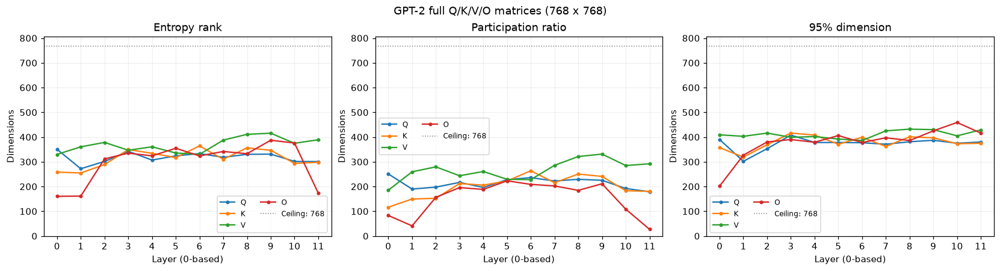

In [7]:
weight_ranks = {name: rank_metrics(torch.linalg.svdvals(w)) for name, w in full_weights.items()}
plot_rank_metrics(weight_ranks, "GPT-2 full Q/K/V/O matrices (768 x 768)", ceiling=768)

## QK, OV Circuits
원 논문의 표기에 따라 헤드 $h$의 두 회로를 정의합니다.

$$
W_{QK}^h=(W_Q^h)^{\mathsf T}W_K^h,
\qquad
W_{OV}^h=W_O^hW_V^h.
$$

QK는 **어디에 주목할지**, OV는 **어떤 정보를 residual에 더할지**를 결정하는 가중치 부분입니다.
목적지 토큰과 원본 토큰의 열벡터를 각각 $x_t,x_s\in\mathbb{R}^{768}$로 두면, 원 논문처럼 상수 스케일링을 생략한 표기는 다음과 같습니다.

$$
\mathrm{score}_{t,s}^h=x_t^{\mathsf T}W_{QK}^h x_s,
\qquad
\mathrm{output}_t^h=\sum_s\alpha_{t,s}^h W_{OV}^h x_s.
$$

$\mathrm{score}_{t,s}^h$는 두 토큰 사이의 점수인 스칼라입니다. $\alpha_{t,s}^h$는 인과 마스크와 softmax를 적용한 attention 가중치입니다.
열벡터에서는 오른쪽 행렬부터 적용하므로, **V 다음 O**의 연산 순서를 $W_OW_Vx$로 표현합니다. 회로 분석에서는 bias와 LayerNorm을 제외합니다.

**행렬곱·외적·텐서곱을 구분합니다.** $A\in\mathbb{R}^{m\times k}$와 $B\in\mathbb{R}^{k\times n}$의 행렬곱은 공유 차원 $k$를 합산합니다.

$$
(AB)_{ij}=\sum_{a=1}^{k}A_{ia}B_{aj},
\qquad AB\in\mathbb{R}^{m\times n}.
$$

열벡터 $u\in\mathbb{R}^{m}$와 $v\in\mathbb{R}^{n}$의 **외적**은 합산 없이 모든 성분 쌍을 곱하여 행렬을 만듭니다.

$$
(uv^{\mathsf T})_{ij}=u_i v_j.
$$

벡터의 텐서곱 $u\otimes v$는 이러한 성분 쌍을 갖는 2차 텐서이며, 행렬로 표현하면 외적에 대응합니다.
행렬의 텐서곱을 나타내는 Kronecker 곱 $A\otimes B$는 각 $A_{ij}$를 블록 $A_{ij}B$로 바꾸는 연산입니다.
원 논문의 $A^h\otimes W_{OV}^h$는 **토큰 사이의 이동**과 **벡터 성분의 변환**을 동시에 나타냅니다.

$$
(A^h\otimes W_{OV}^h)
\begin{bmatrix}x_1\\\vdots\\x_T\end{bmatrix}
=
\begin{bmatrix}
\sum_s A_{1s}^hW_{OV}^hx_s\\
\vdots\\
\sum_s A_{Ts}^hW_{OV}^hx_s
\end{bmatrix}.
$$

$T$는 토큰 수이고 $A_{ts}^h=\alpha_{t,s}^h$입니다. $A^h$는 $T\times T$ 행렬이므로 위 텐서곱의 크기는 $(768T)\times(768T)$입니다.
반면 $W_Q^{\mathsf T}W_K$와 $W_OW_V$ 자체는 **공유 차원을 합산하는 행렬곱**입니다. 각 곱은 64개의 외적을 더한 형태로 풀어 쓸 수 있습니다.

$$
W_{QK}^h=\sum_{a=1}^{64}q_a k_a^{\mathsf T},
\qquad
W_{OV}^h=\sum_{a=1}^{64}o_a v_a^{\mathsf T}.
$$

$q_a^{\mathsf T},k_a^{\mathsf T},v_a^{\mathsf T}$는 각 Q·K·V 행렬의 $a$번째 행이고, $o_a$는 O 행렬의 $a$번째 열입니다.
외적 하나의 랭크는 최대 1이므로, 두 회로는 $768\times768$ 행렬이지만 랭크가 최대 64입니다.

### 1. torch.linalg.matrix_rank
헤드별 QK·OV 행렬에 `torch.linalg.matrix_rank`를 적용하고, 각 레이어의 12개 헤드에 대한 평균과 최솟값·최댓값을 표시합니다.

In [8]:
circuit_matrix_ranks = circuit_matrix_rank(circuit_factors)
show_matrix_rank(circuit_matrix_ranks, per_head=True)

torch.linalg.matrix_rank | CPU float64 | default tolerance
Layer                QK                OV
        mean [min, max]   mean [min, max]
    0     64.0 [64, 64]     64.0 [64, 64]
    1     64.0 [64, 64]     64.0 [64, 64]
    2     64.0 [64, 64]     64.0 [64, 64]
    3     64.0 [64, 64]     64.0 [64, 64]
    4     64.0 [64, 64]     64.0 [64, 64]
    5     64.0 [64, 64]     64.0 [64, 64]
    6     64.0 [64, 64]     64.0 [64, 64]
    7     64.0 [64, 64]     64.0 [64, 64]
    8     64.0 [64, 64]     64.0 [64, 64]
    9     64.0 [64, 64]     64.0 [64, 64]
   10     64.0 [64, 64]     64.0 [64, 64]
   11     64.0 [64, 64]     64.0 [64, 64]


### 2. Effective Rank
QK·OV에도 $p_i=\sigma_i^2/\sum_j\sigma_j^2$를 적용하여 세 유효 랭크 지표를 계산합니다.
그래프의 **선은 헤드 평균**, **음영은 헤드별 최솟값부터 최댓값까지의 범위**를 나타냅니다.

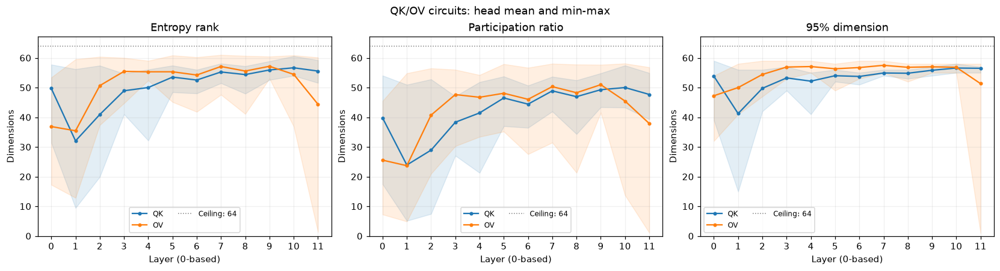

In [9]:
circuit_ranks = {name: rank_metrics(product_singular_values(a, b))
                 for name, (a, b) in circuit_factors.items()}
plot_rank_metrics(circuit_ranks, "QK/OV circuits: head mean and min-max", ceiling=64, per_head=True)

## Copying Behavior: OV 고유분해
헤드별 OV 행렬을 $M=W_O^hW_V^h\in\mathbb{R}^{768\times768}$로 정의합니다.
열벡터 업데이트 $Mx$에서 방향이 어떻게 변하는지 확인하기 위해 **오른쪽 고유벡터**의 관계를 사용합니다.

$$
Mv=\lambda v,
\qquad v\ne0.
$$

$v$는 고유벡터, $\lambda$는 고윳값입니다. 입력 $v$가 $\lambda v$로 변환되는 관계를 나타냅니다.
OV는 일반적으로 비대칭이므로 `eig`를 사용하며 복소 고윳값도 유지합니다.

계산은 작은 행렬로 줄일 수 있습니다. $A=W_O^h\in\mathbb{R}^{768\times64}$,
$B=W_V^h\in\mathbb{R}^{64\times768}$로 두면 $M=AB$이며 다음 관계가 성립합니다.

$$
BAu=\lambda u
\quad\Longrightarrow\quad
AB(Au)=A(BAu)=\lambda(Au).
$$

따라서 0이 아닌 고윳값은 $64\times64$ 행렬 $BA$에서 계산합니다. 고유벡터가 필요하면 $BA$의 고유벡터 $u$로부터 $v=Au$를 계산하여 768차원으로 복원할 수 있습니다.
원래 행렬에 존재하는 최소 704개의 0 고윳값은 그림에서 제외합니다.

- $\lambda>0$인 **실수 고윳값**은 해당 방향의 부호를 보존합니다. $0<\lambda<1$이면 감쇠하고, $\lambda>1$이면 증폭합니다.
- $\lambda<0$인 실수 고윳값은 해당 방향의 부호를 반전합니다.
- 복소 고윳값은 실수부가 양수여도 양의 실수 고윳값으로 세지 않습니다.

첫 그림은 헤드별 **0이 아닌 고윳값 중 양의 실수 고윳값의 비율**을 표시합니다.
두 번째 그림은 [원 논문의 원형 산점도](https://transformer-circuits.pub/2021/framework/index.html#copying-matrix) 형식으로 모든 레이어와 헤드의 고윳값을 표시합니다.
**행은 레이어, 열은 헤드**입니다. 각 점은 0이 아닌 고윳값 하나이며 다음 좌표를 사용합니다.

$$
\theta=\arg(\lambda),\qquad \rho=\log_{10}|\lambda|+C.
$$

$\arg(\lambda)$는 복소평면에서의 각도이며, 양의 실수는 오른쪽, 음의 실수는 왼쪽에 놓입니다.
$C$는 반지름을 양수로 옮기는 공통 상수입니다. 동심원의 눈금은 원래 크기 $|\lambda|$를 나타냅니다.
모든 칸에 동일한 로그 척도를 적용하며, 주황색은 양의 실수 고윳값, 파란색은 나머지 고윳값을 표시합니다.
그림 형식은 논문을 따르며 분석 행렬은 $M=W_OW_V$를 사용합니다.

양의 고윳값은 residual 특징의 보존 성향을 나타냅니다. 특정 토큰의 복사를 확인하려면 $W_U M W_E$와 실제 attention·logit 효과를 함께 분석해야 합니다.
$W_E$는 토큰을 residual 공간으로 보내는 임베딩 행렬이고, $W_U$는 residual을 토큰별 logit으로 보내는 출력 행렬입니다.

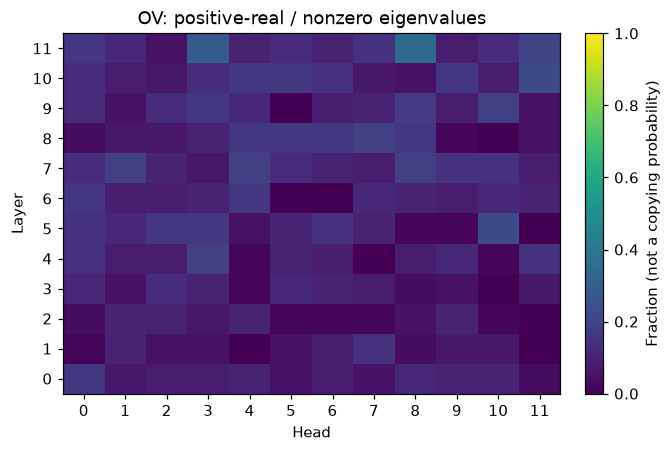

In [11]:
ov_factors = {"OV": circuit_factors["OV"]}
eigenvalues, positive_real_fraction = plot_circuit_spectra(ov_factors)

In [12]:
ov_spectrum_figure = plot_ov_eigenvalue_grid(eigenvalues["OV"])

12 layers x 12 heads | 9216 nonzero eigenvalues displayed


## 결론 및 요약

**1. Residual stream은 임베딩에서 누적된 변화를 나타냅니다.**

$$
r_t^{(0)}=W_Ee_t+p_t,
\qquad
\Delta r_{\ell,t}=r_{\ell,t}^{\mathrm{post}}-r_t^{(0)}.
$$

Prefill은 모든 토큰을 처리하고, KV cache를 사용하는 decode는 새 토큰만 처리합니다. 그림의 이전 토큰 행은 표시용으로 0 처리합니다.

**2. 수치 랭크와 유효 랭크는 서로 다른 정보를 나타냅니다.**

$$
p_i=\frac{\sigma_i^2}{\sum_j\sigma_j^2},
\qquad
r_{\mathrm{entropy}}=\exp\!\left(-\sum_i p_i\log p_i\right),
\qquad
r_{\mathrm{PR}}=\frac{1}{\sum_i p_i^2},
\qquad
 d_{95}=\min\left\{k:\sum_{i=1}^{k}p_i\geq0.95\right\}.
$$

이번 GPT-2 실험에서 전체 Q·K·V·O의 수치 랭크는 모두 768입니다. 유효 랭크는 그보다 작으며, 에너지가 일부 방향에 집중되어 있음을 보여줍니다.

**3. QK는 attention 위치를, OV는 전달할 정보를 결정합니다.**

$$
W_{QK}^h=(W_Q^h)^{\mathsf T}W_K^h,
\qquad
W_{OV}^h=W_O^hW_V^h,
\qquad
\operatorname{rank}(W_{QK}^h),\operatorname{rank}(W_{OV}^h)\leq64.
$$

두 회로는 $768\times768$ 행렬이지만 64차원 헤드를 거칩니다. 이번 실험의 헤드별 수치 랭크는 모두 64입니다.

**4. 양의 OV 고윳값은 특징 보존의 단서입니다.**

$$
W_{OV}^h v=\lambda v,
\qquad
\lambda>0\ \Rightarrow\ \text{해당 실수 고유방향의 부호 보존}.
$$

OV에는 음의 실수와 복소 고윳값도 존재합니다. 토큰 복사는 $W_UW_{OV}^hW_E$와 실제 attention·logit 효과를 함께 확인해야 합니다.